In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
DATA_PATH = Path("../data/train.csv")

df = pd.read_csv(DATA_PATH)
X = df["text"].astype(str)
y = df["label"]
print("Total examples:", len(X))
print("Classes:", sorted(y.unique()))

Total examples: 400
Classes: ['account-access', 'fraud-report', 'general', 'transaction-dispute']


In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=30
)

print("Training examples:", X_train.shape[0])
print("Validation examples:", X_val.shape[0])

print("\nTrain class distribution:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nValidation class distribution:")
print((y_val.value_counts(normalize=True) * 100).round(2))

Training examples: 320
Validation examples: 80

Train class distribution:
label
general                40.0
account-access         25.0
transaction-dispute    22.5
fraud-report           12.5
Name: proportion, dtype: float64

Validation class distribution:
label
general                40.0
account-access         25.0
transaction-dispute    22.5
fraud-report           12.5
Name: proportion, dtype: float64


In [6]:
variant_2_model = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                stop_words="english"
            )
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=30
            )
        )
    ]
)

variant_2_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before 

In [7]:
variant_2_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](4,)","['account-access','fraud-report','general','transaction-dispute']"
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.

In [8]:
y_pred_v2 = variant_2_model.predict(X_val)

print("Predictions completed for Version 2.")
print("Number of validation predictions:", len(y_pred_v2))

Predictions completed for Version 2.
Number of validation predictions: 80


In [9]:
accuracy_v2 = accuracy_score(y_val, y_pred_v2)

macro_f1_v2 = f1_score(
    y_val,
    y_pred_v2,
    average="macro"
)

weighted_f1_v2 = f1_score(
    y_val,
    y_pred_v2,
    average="weighted"
)

fraud_recall_v2 = recall_score(
    y_val,
    y_pred_v2,
    labels=["fraud-report"],
    average="macro",
    zero_division=0
)

print("Version 2 Results")
print("-----------------")
print("Model: TF-IDF unigrams + Logistic Regression")
print("Class weighting: balanced")
print("Accuracy:", round(accuracy_v2, 4))
print("Macro F1:", round(macro_f1_v2, 4))
print("Weighted F1:", round(weighted_f1_v2, 4))
print("Fraud-report recall:", round(fraud_recall_v2, 4))

Version 2 Results
-----------------
Model: TF-IDF unigrams + Logistic Regression
Class weighting: balanced
Accuracy: 1.0
Macro F1: 1.0
Weighted F1: 1.0
Fraud-report recall: 1.0


In [10]:
print("Classification Report - Version 2")
print(classification_report(y_val, y_pred_v2))

Classification Report - Version 2
                     precision    recall  f1-score   support

     account-access       1.00      1.00      1.00        20
       fraud-report       1.00      1.00      1.00        10
            general       1.00      1.00      1.00        32
transaction-dispute       1.00      1.00      1.00        18

           accuracy                           1.00        80
          macro avg       1.00      1.00      1.00        80
       weighted avg       1.00      1.00      1.00        80



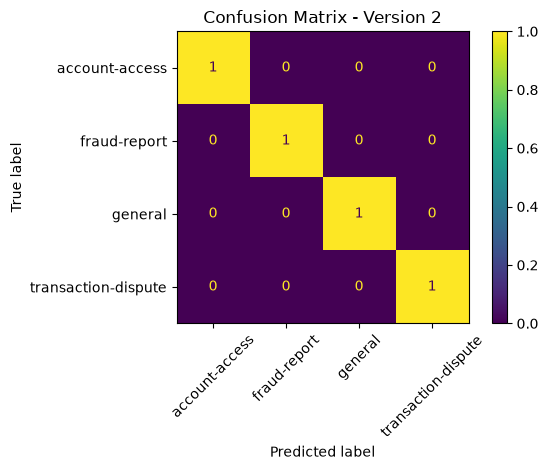

In [12]:
labels = sorted(y.unique())

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred_v2,
    labels=labels,
    normalize="true",
    xticks_rotation=45
)

plt.title("Confusion Matrix - Version 2")
plt.tight_layout()
plt.show()

In [13]:
import joblib

In [14]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

V2_MODEL_PATH = MODEL_DIR / "v2_tfidf_logreg_balanced.joblib"

joblib.dump(variant_2_model, V2_MODEL_PATH)

print(f"V2 model saved to: {V2_MODEL_PATH}")

V2 model saved to: ../models/v2_tfidf_logreg_balanced.joblib
